# Toy example to check KL div loss

In [1]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import wandb

from nnfabrik.utility.nn_helpers import set_random_seed


seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 5
torch.cuda.set_device(f"cuda:{cuda_number}")
device = f'cuda:{cuda_number}'

In [2]:
cluster_number=2
dec_starting_epoch=30
alpha=1.0
kmeans_init=20
base_multiplier=4e3
exponent=1.2
data_spread = 5

In [3]:
from sklearn.datasets import make_blobs

# Generate a 5D dataset with two clusters
n_samples = 2000
n_features = 4
n_clusters = cluster_number
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, random_state=42)
max_abs = 10  # Example threshold
X = X / np.max(np.abs(X), axis=0) 

# Print shape to verify
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (2000, 4)
Labels shape: (2000,)


In [4]:
def generate_functions():
    functions = []

    # Cluster 1: Small variations (close to np.sum(X, axis=1))
    for i in range(250):
        shift = np.random.uniform(0, 0.001)  # Tiny shifts
        functions.append(lambda X, s=shift: np.sum(X, axis=1) + s)

    # Cluster 2: Large shifts (well-separated from cluster 1)
    for i in range(250):
        shift = np.random.uniform(10, 10.5)  # Large shifts
        functions.append(lambda X, s=shift: np.sum(X, axis=1) + s)

    return functions

# Apply functions
def apply_functions(X):
    functions = generate_functions()
    return np.column_stack([f(X) for f in functions])

f = apply_functions(X)
print(f[0,:])

[-1.41733038 -1.41675421 -1.41697293 -1.41710626 -1.4175489  -1.41754893
 -1.41764684 -1.41683874 -1.41710381 -1.41699685 -1.41768434 -1.41673501
 -1.41687248 -1.41749258 -1.4175231  -1.41752152 -1.41740068 -1.41718016
 -1.41727298 -1.41741369 -1.41709307 -1.41756543 -1.41741278 -1.41733856
 -1.41724885 -1.41691974 -1.41750525 -1.41719069 -1.41711251 -1.41765847
 -1.41709738 -1.4175344  -1.41763987 -1.41675604 -1.41673929 -1.41689652
 -1.41740031 -1.41760725 -1.41702069 -1.41726477 -1.41758288 -1.41720974
 -1.41767053 -1.4167956  -1.41744614 -1.4170424  -1.41739321 -1.41718485
 -1.41715821 -1.41752007 -1.41673534 -1.41692979 -1.41676542 -1.41681009
 -1.41710702 -1.41678305 -1.41761643 -1.41750894 -1.41765969 -1.41737959
 -1.41731624 -1.41743357 -1.41687618 -1.41734817 -1.41742399 -1.41716222
 -1.417564   -1.41690272 -1.41763037 -1.41671803 -1.41693268 -1.41750621
 -1.4176994  -1.41688946 -1.41699806 -1.41697591 -1.41693365 -1.41763088
 -1.41734646 -1.41758905 -1.41684182 -1.41708162 -1

Visualisation using kmeans

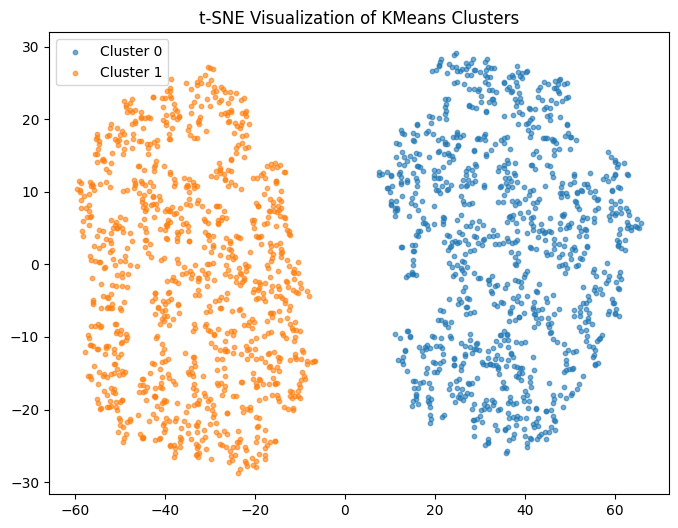

In [5]:
def kmeans_clustering(features, n_clusters=10):
    """Performs KMeans clustering on extracted features."""
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    predictions = kmeans.fit_predict(features)
    return kmeans, predictions

def visualize_tsne(features, predictions, n_clusters=10):
    """Performs t-SNE and visualizes clusters."""
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_features = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    for i in range(n_clusters):
        plt.scatter(
            reduced_features[predictions == i, 0], reduced_features[predictions == i, 1], 
            label=f'Cluster {i}', alpha=0.6, s=10,
        )
    
    plt.legend()
    plt.title("t-SNE Visualization of KMeans Clusters")
    plt.show()

def main(data, labels, n_clusters=10, device="cuda"):
    kmeans, predictions = kmeans_clustering(data, n_clusters)
    visualize_tsne(data, predictions, n_clusters)
    

main(X, y, n_clusters=2)

In [6]:
# create dataset
class ClusteredDataset(Dataset):
    def __init__(self, cluster_number=cluster_number, n_features=n_features, n_samples=n_samples, seed=42):
        np.random.seed(seed)

        X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=cluster_number, random_state=seed)
        labels = apply_functions(X)

        # Print shape to verify
        print("Feature matrix shape:", X.shape)
        print("Labels shape:", labels.shape)

        self.data = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Function to load the dataset
def load_dataset(batch_size=128, cluster_number=2,n_features=4,n_samples=2000):
    dataset = ClusteredDataset(cluster_number=cluster_number, n_features=n_features, n_samples=n_samples)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), dataset

In [7]:
# simple linear model
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self, input_dim, output_dim=500):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  # Directly define the layer

    def forward(self, x):
        return self.linear(x)  # No need for Sequential

In [8]:
def soft_assignments_mult(encoded_features, cluster_centers, sigma, alpha=1, p=1):
    sigma_inv = 1.0 / sigma  # (K,)
    diff = (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) #(N,K,D)
    print(diff.shape)
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    det = torch.sqrt(torch.prod(sigma, dim=1))
    print('det', det.shape)
    assignments = 1.0 / (1.0 + (norm_sigma / alpha))
    assignments = (assignments ** ((alpha + p) / 2))/det
    print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

def target_distribution(batch: torch.Tensor, exponent=exponent) -> torch.Tensor:
    weight = (batch**exponent) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()

def EM_t_mult(features, resp, cluster_centers, sigma, alpha, d=1):
    sigma_inv = 1.0 / sigma  # (K,)
    diff = (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0))
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    u = (alpha + d)/(alpha +norm_sigma)  #ccalculate U shape(N,K)
    print('u', u.shape)
    print(resp.shape)
    
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sq_diff = resp.unsqueeze(2)* u.unsqueeze(2) * (diff ** 2)  # (N, K, D)
    numerator = weighted_sq_diff.sum(dim=0) #(K,D)
    denominator = torch.sum(resp, dim=0, keepdim=True)  # (K,)
    print('sigma de', denominator.shape)
    sigma = (numerator / denominator.T).detach()
    print('Tau', sigma.shape)
    return cluster_centers, sigma

In [19]:
def EM_t_1D(features, resp, cluster_centers, taus, alpha, d=1):
    norm_squared = torch.sum(
    (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, dim=2
    )  
    u = (alpha + d)/(alpha +norm_squared*(taus**(-1)))  #ccalculate U shape(N,K)
    print('u', u.shape)
    print(resp.shape)
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sums = torch.sum(resp* u * norm_squared, dim=0) 
    #print('WS', weighted_sums.shape)
    taus = (weighted_sums / torch.sum(resp, dim=0, keepdim=True)).detach()
    #print('Tau', taus.shape)
    return cluster_centers, taus


def soft_assignments_1D(encoded_features, cluster_centers, tau, alpha=1, p=1):
    norm_squared = torch.sum(
        (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, 2
    )
    assignments = 1.0 / (1.0 + (norm_squared / (alpha * tau)))
    assignments = (assignments ** ((alpha + p) / 2))/(tau**1/2)
    #print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

In [29]:
def trainer(model, dataloader, cluster_number=cluster_number, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_wandb = True,
            use_diag_cov=True,
            learn_alpha=True,
            exponent=exponent, lr=0.01, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    '''
    if learn_alpha:
        alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        optimizer = torch.optim.Adam(list(model.parameters()) + [alpha], lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()
    def repulsion_loss(cluster_centers, epsilon=1e-6):
        'Regularization term that penalizes small distances between clusters'
        pairwise_distances = torch.cdist(cluster_centers, cluster_centers, p=2)  # Compute pairwise distances
        pairwise_distances = torch.triu(pairwise_distances, diagonal=1)  # Keep only upper triangle (ignores diagonal)
        return torch.sum(1.0 / (pairwise_distances + epsilon)) 
    if use_wandb:
        wandb.init(
            project='Toy example',
            entity='ninasophie-nellen-g-ttingen-university',
            name='toy run higher dimensoinal epsilon 10 repulsion, 1 backpropagation',
            config={
                "learning_rate": lr,
                "cur_epochs": epochs,
            },
        )
        wandb.run.log_code(".")
        # metrics represent any value I want to track, if they're hidden, they're not displayed on default cisualisation
        wandb.define_metric(name="Epoch", hidden=True)
        wandb.define_metric(name="Batch", hidden=True)

    model.to(device)
    model.train()
    for epoch in range(epochs):

        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0
        '''
        if epoch >= 50:
            lr = 0.0005
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        '''
        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            print(features.shape)
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device, requires_grad=True,
            )
            if use_diag_cov:
                p = features.shape[1]
                sigma = torch.zeros((cluster_number,p), device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k] = torch.var(cluster_points, dim=0, unbiased=True)

            else: 
                sigma = torch.zeros(cluster_number, device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device)  
                    if len(cluster_points) > 0:
                        sigma[k] = torch.mean(torch.sum((cluster_points - cluster_centers[k])**2,1))
                sigma = sigma.unsqueeze(0)
                print('Tau beginning', sigma)
                p=1
            print('p',p)
            alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            
            tsne = TSNE(n_components=2, perplexity=30, random_state=42)
            reduced_features = tsne.fit_transform(features)

            plt.figure(figsize=(8, 6))
            plt.scatter(
                reduced_features[:, 0], reduced_features[:, 1], alpha=0.6, s=10,)
            plt.title("t-SNE Visualization of KMeans Clusters")
            plt.show()

        for i, (inputs, labels) in enumerate(dataloader): 
            #if epoch < dec_starting_epoch:
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 
            if epoch >= dec_starting_epoch:
                loss = torch.zeros(1, device=device)
            epoch_loss += loss.detach()
            epoch_loss_main += loss.detach() 
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T
                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, alpha,p)
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)
                target = target_distribution(q, exponent)
                '''
                if epoch < dec_starting_epoch + 1:
                    print('Q', q)
                    print('Targets', target)
                '''
                kldiv_loss = 10 * kldiv_criterion(q.log(), target)
                kldiv_loss.backward()
                epoch_kldiv_loss += kldiv_loss.detach()
                #print('KL loss', kldiv_loss)
                epoch_loss += kldiv_loss.detach()
                if use_diag_cov:
                    cluster_centers, sigma = EM_t_mult(features, q, cluster_centers, sigma, alpha, p)
                else:
                    cluster_centers, sigma = EM_t_1D(features, q, cluster_centers, sigma, alpha, p)
                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
            optimizer.step()  
            optimizer.zero_grad()   

        #print(f"Epoch {epoch}, loss: {loss}")
        if epoch >= dec_starting_epoch:
            print('Q',q)
        if use_wandb:
            wandb_dict = {
                "Epoch Train loss": epoch_loss,
                "Epoch Train loss main": epoch_loss_main,
                "Epoch Train loss Kullback-Leibler-divergence": epoch_kldiv_loss,
            }
            wandb.log(wandb_dict)

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()
    print(cluster_centers)
    print("Training Complete!")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)

    print('features: ', features.shape)
    print('predictions: ', predictions.shape)
    print('cluster centers ', cluster_centers_np.shape)
    print('TAu', sigma)
    return features, predictions, cluster_centers_np

Feature matrix shape: (2000, 5)
Labels shape: (2000, 500)


/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


(500, 5)
p 5


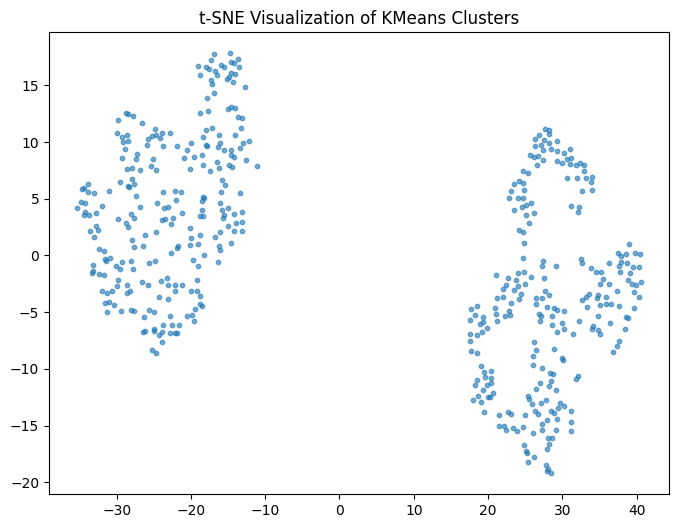

torch.Size([500, 2, 5])
det torch.Size([2])
Assignments shape torch.Size([500, 2])
u torch.Size([500, 2])
torch.Size([500, 2])
torch.Size([2, 5])
torch.Size([2, 1])
sigma de torch.Size([1, 2])
Tau torch.Size([2, 5])
torch.Size([500, 2, 5])
det torch.Size([2])
Assignments shape torch.Size([500, 2])
u torch.Size([500, 2])
torch.Size([500, 2])
torch.Size([2, 5])
torch.Size([2, 1])
sigma de torch.Size([1, 2])
Tau torch.Size([2, 5])
torch.Size([500, 2, 5])
det torch.Size([2])
Assignments shape torch.Size([500, 2])
u torch.Size([500, 2])
torch.Size([500, 2])
torch.Size([2, 5])
torch.Size([2, 1])
sigma de torch.Size([1, 2])
Tau torch.Size([2, 5])
torch.Size([500, 2, 5])
det torch.Size([2])
Assignments shape torch.Size([500, 2])
u torch.Size([500, 2])
torch.Size([500, 2])
torch.Size([2, 5])
torch.Size([2, 1])
sigma de torch.Size([1, 2])
Tau torch.Size([2, 5])
torch.Size([500, 2, 5])
det torch.Size([2])
Assignments shape torch.Size([500, 2])
u torch.Size([500, 2])
torch.Size([500, 2])
torch.Siz

In [ ]:
dataloader, dataset = load_dataset(batch_size=256, n_features=5)
model = SimpleNN(input_dim=5)
features, predictions, cluster_centers_list = trainer(model, dataloader, dec_starting_epoch=30, 
                                                      exponent=2, epochs=100, use_wandb=False, 
                                                      use_diag_cov=True, learn_alpha=True, alpha=1)

In [22]:
cluster_centers = cluster_centers_list[-1]
print(cluster_centers)
print(features)

[[ 0.8430724   0.5222808   0.6288461   0.76383793  0.25361937]
 [-0.69974947  0.5910514   0.9239953   0.91737854 -0.32772192]]
[[ 0.8430808   0.52226067  0.62827426  0.7638338   0.25395766]
 [-0.37113765  0.8869933   0.06258182  0.74759334  0.49345613]
 [ 0.8430668   0.5224935   0.62906444  0.7638562   0.25403252]
 ...
 [-0.6992789   0.59133065  0.92415345  0.91746354 -0.3272255 ]
 [-0.69927996  0.5914943   0.92413616  0.9174717  -0.32754302]
 [-0.6995078   0.59136856  0.9242666   0.9175309  -0.32723108]]


In [27]:
from sklearn.manifold import TSNE

def visualize_clusters(features, predictions, cluster_centers):

    n = features.shape[0]
    perplexity = 30
    #n/100
    lr = n/12
    print(features.shape)
    print(cluster_centers.shape)

    plt.figure(figsize=(8,10), dpi=80)

    colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters
    color_map = {label: colors(i) for i, label in enumerate(range(cluster_number))}

    combined_data = np.vstack([features, cluster_centers])  # Stack features with centers

    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

    embedded_points = embedded_data[:n]  # First part corresponds to data points
    embedded_centers = embedded_data[n:]  # Last part corresponds to cluster centers

    for value in range(cluster_number):
        cluster_mask = predictions == value
        print(f"Cluster {value}: Mask shape = {cluster_mask.shape}, Points = {cluster_mask.sum()}")
        
        plt.scatter(
            embedded_points[cluster_mask, 0],
            embedded_points[cluster_mask, 1],
            c=[color_map[value]],
            label=f'Cluster {value}',
            alpha=0.7,
            s=1,
        )
        plt.scatter(
            embedded_centers[value][0],
            embedded_centers[value][1],
            c=[color_map[value]],  # Mapped color
            marker='X',
            s=100,
            edgecolor='black',
            label='Cluster Center'
        )

    plt.title(f'clustered data')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Add legend automatically from the scatter plot
    plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
    plt.show()

(500, 5)
(2, 5)


/tmp/ipykernel_1693316/1217165365.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters


Cluster 0: Mask shape = (500,), Points = 180
Cluster 1: Mask shape = (500,), Points = 320


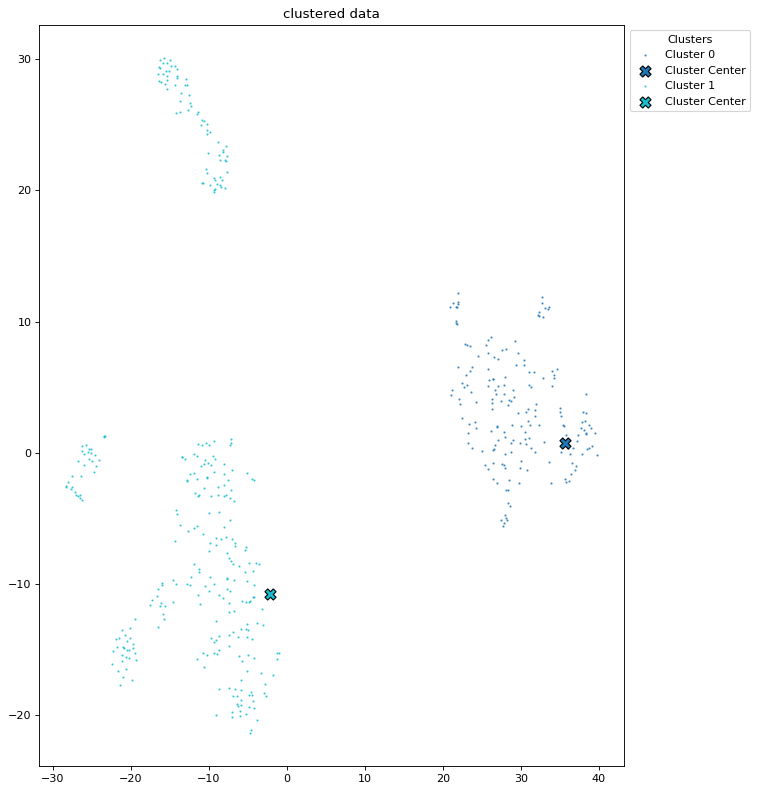

In [28]:
visualize_clusters(features, predictions, cluster_centers_list[-1])

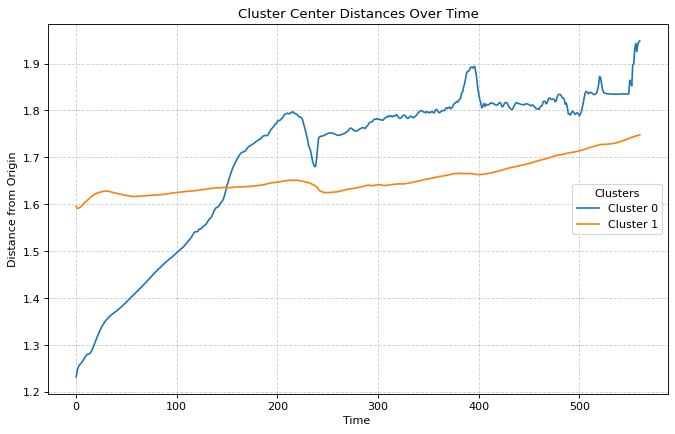

In [18]:
time = cluster_centers_list.shape[0]
end_time =time
cluster_centers_distances=np.zeros((time, cluster_number)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_list[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)


for cluster_idx in range(cluster_number):
    #if cluster_idx in unique_values:
    plt.plot(range(end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx}')

#plt.plot(range(end_time),kldiv_loss_batches[: end_time], label = 'kldiv_loss')
plt.xlabel('Time ')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time')
plt.legend(title='Clusters', loc='center right', frameon=True)
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()